# Model Comparison

This notebook compares all 4 models trained on the **same common preprocessed dataset**.

**Prerequisite:** Run all model notebooks (01-04) first to generate saved metrics.

### Models Compared:
1. Linear Regression (scaled features)
2. Decision Tree Regression (unscaled features)
3. Random Forest Regression (unscaled features)
4. Support Vector Regression (scaled features)

In [1]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

import joblib
import os
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


## 1. Load Common Preprocessed Data & Models

In [2]:
# Load preprocessed data
data_dir = '../data/preprocessed'

X_train = pd.read_csv(f'{data_dir}/X_train.csv')
X_test = pd.read_csv(f'{data_dir}/X_test.csv')
X_train_scaled = pd.read_csv(f'{data_dir}/X_train_scaled.csv')
X_test_scaled = pd.read_csv(f'{data_dir}/X_test_scaled.csv')
y_train = pd.read_csv(f'{data_dir}/y_train.csv').squeeze()
y_test = pd.read_csv(f'{data_dir}/y_test.csv').squeeze()

print(f"Loaded common preprocessed data:")
print(f"  Training samples: {len(X_train)}")
print(f"  Testing samples:  {len(X_test)}")
print(f"  Features: {X_train.shape[1]}")

Loaded common preprocessed data:
  Training samples: 5285
  Testing samples:  1322
  Features: 19


In [3]:
# Load saved models
model_dir = '../models'

lr_model = joblib.load(f'{model_dir}/linear_regression_model.pkl')
dt_model = joblib.load(f'{model_dir}/decision_tree_model.pkl')
rf_model = joblib.load(f'{model_dir}/random_forest_model.pkl')
svr_model = joblib.load(f'{model_dir}/svr_model.pkl')

print("All 4 models loaded successfully!")

All 4 models loaded successfully!


## 2. Generate Predictions

In [4]:
# Generate predictions from all models
# Linear Regression & SVR use SCALED data
# Decision Tree & Random Forest use UNSCALED data

predictions = {
    'Linear Regression': lr_model.predict(X_test_scaled),
    'Decision Tree': dt_model.predict(X_test),
    'Random Forest': rf_model.predict(X_test),
    'SVR': svr_model.predict(X_test_scaled)
}

print("Predictions generated for all 4 models.")

Predictions generated for all 4 models.


## 3. Performance Comparison Table

In [5]:
# Calculate metrics for all models
results = []

for model_name, y_pred in predictions.items():
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({
        'Model': model_name,
        'MAE': round(mae, 4),
        'RMSE': round(rmse, 4),
        'R² Score': round(r2, 4)
    })

comparison_df = pd.DataFrame(results)
comparison_df = comparison_df.sort_values('R² Score', ascending=False).reset_index(drop=True)

print("=" * 60)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 60)
print(f"\nAll models trained on the SAME preprocessed dataset")
print(f"Training samples: {len(X_train)} | Testing samples: {len(X_test)}")
print(f"\n{comparison_df.to_string(index=False)}")

MODEL PERFORMANCE COMPARISON

All models trained on the SAME preprocessed dataset
Training samples: 5285 | Testing samples: 1322

            Model    MAE   RMSE  R² Score
              SVR 0.7485 1.9520    0.7304
Linear Regression 1.0155 2.0974    0.6888
    Random Forest 1.1314 2.2095    0.6546
    Decision Tree 1.5896 2.5366    0.5448


## 4. Cross-Validation Comparison

In [6]:
# Cross-validation comparison (5-fold)
X_all = pd.concat([X_train, X_test])
X_all_scaled = pd.concat([X_train_scaled, X_test_scaled])
y_all = pd.concat([y_train, y_test])

cv_results = {}
models_cv = {
    'Linear Regression': (lr_model, X_all_scaled),
    'Decision Tree': (dt_model, X_all),
    'Random Forest': (rf_model, X_all),
    'SVR': (svr_model, X_all_scaled)
}

print("5-Fold Cross-Validation R² Scores:")
print("=" * 60)
for name, (model, X_data) in models_cv.items():
    scores = cross_val_score(model, X_data, y_all, cv=5, scoring='r2')
    cv_results[name] = scores
    print(f"{name:25s} | Mean: {scores.mean():.4f} (+/- {scores.std():.4f}) | Folds: {scores.round(4)}")

5-Fold Cross-Validation R² Scores:
Linear Regression         | Mean: 0.6602 (+/- 0.0963) | Folds: [0.6608 0.8112 0.6275 0.5128 0.6887]
Decision Tree             | Mean: 0.5098 (+/- 0.0792) | Folds: [0.5172 0.6135 0.503  0.3708 0.5447]
Random Forest             | Mean: 0.6351 (+/- 0.0900) | Folds: [0.6461 0.7727 0.609  0.4924 0.6551]
SVR                       | Mean: 0.6922 (+/- 0.0942) | Folds: [0.71   0.8264 0.6544 0.54   0.7303]


## 5. Visual Comparison

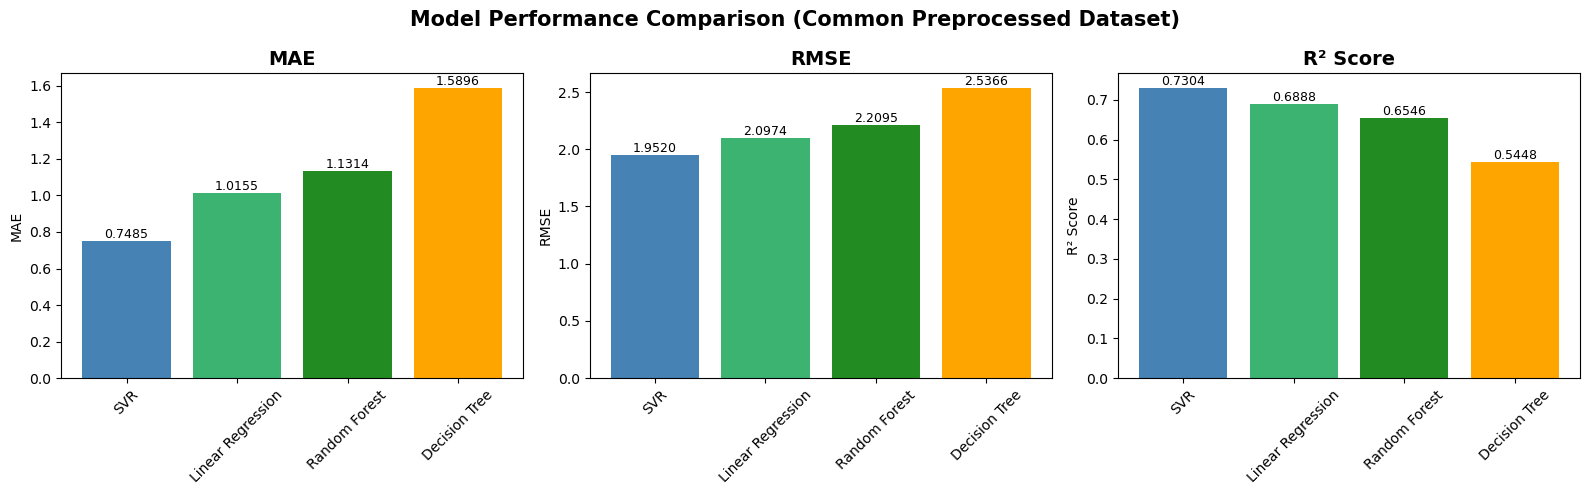

In [7]:
# Bar chart comparison of all metrics
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'mediumseagreen', 'forestgreen', 'orange']

metrics = ['MAE', 'RMSE', 'R² Score']
for i, metric in enumerate(metrics):
    values = comparison_df[metric].values
    models = comparison_df['Model'].values
    bars = axes[i].bar(models, values, color=colors[:len(models)])
    axes[i].set_title(metric, fontsize=14, fontweight='bold')
    axes[i].set_ylabel(metric)
    axes[i].tick_params(axis='x', rotation=45)
    # Add value labels on bars
    for bar, val in zip(bars, values):
        axes[i].text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                    f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Model Performance Comparison (Common Preprocessed Dataset)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

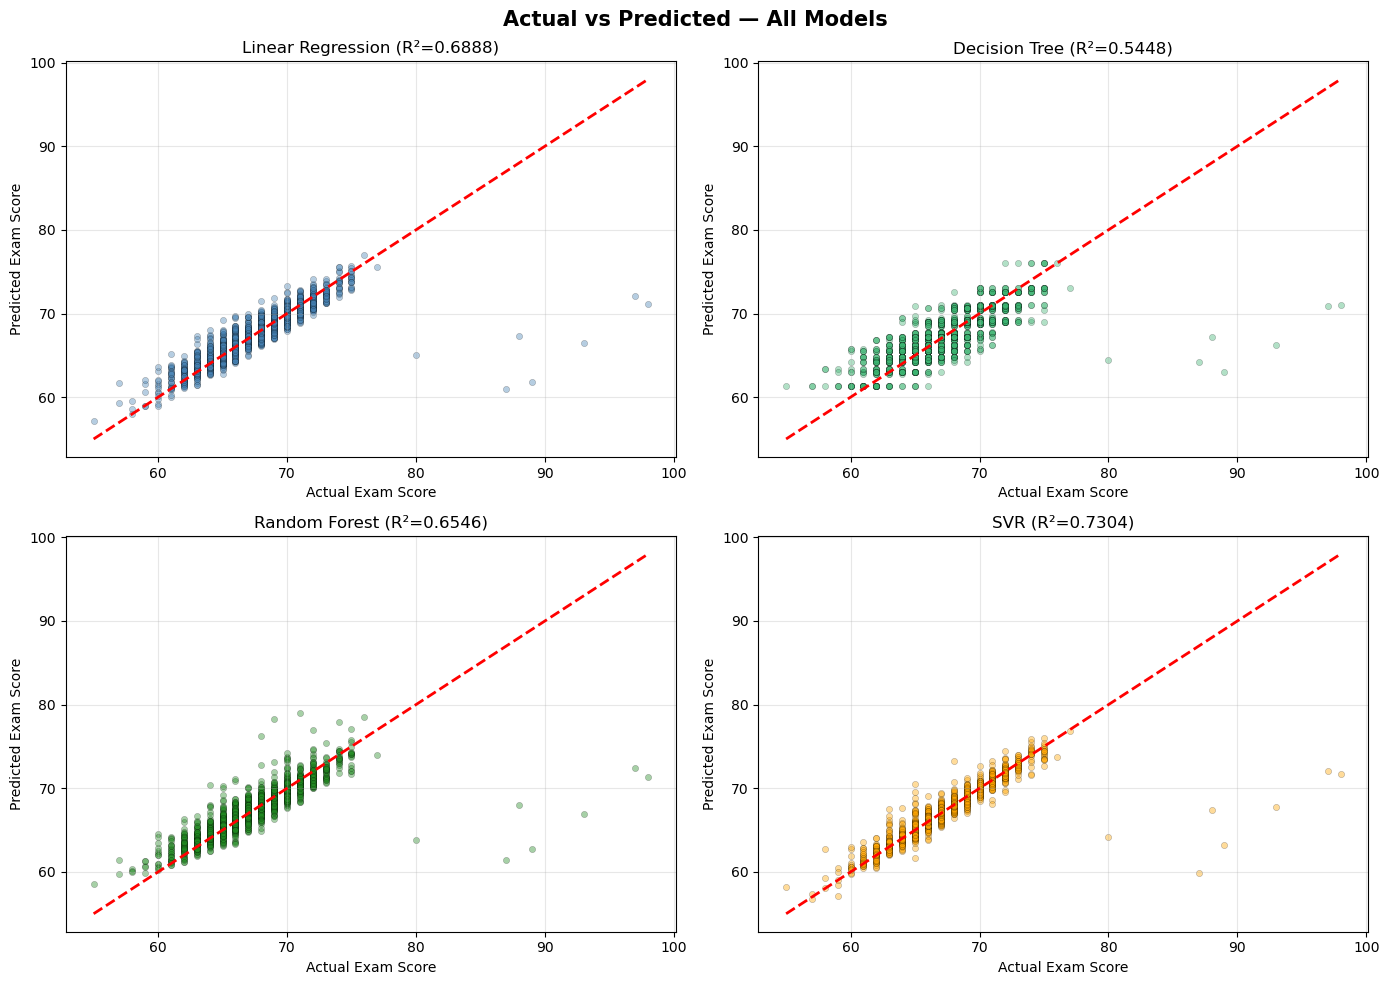

In [8]:
# Actual vs Predicted comparison (all 4 models side by side)
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
model_colors = ['steelblue', 'mediumseagreen', 'forestgreen', 'orange']

for idx, (model_name, y_pred) in enumerate(predictions.items()):
    ax = axes[idx // 2, idx % 2]
    ax.scatter(y_test, y_pred, alpha=0.4, color=model_colors[idx], edgecolors='k', linewidths=0.3, s=20)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    ax.set_xlabel('Actual Exam Score')
    ax.set_ylabel('Predicted Exam Score')
    r2 = r2_score(y_test, y_pred)
    ax.set_title(f'{model_name} (R²={r2:.4f})')
    ax.grid(True, alpha=0.3)

plt.suptitle('Actual vs Predicted — All Models', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

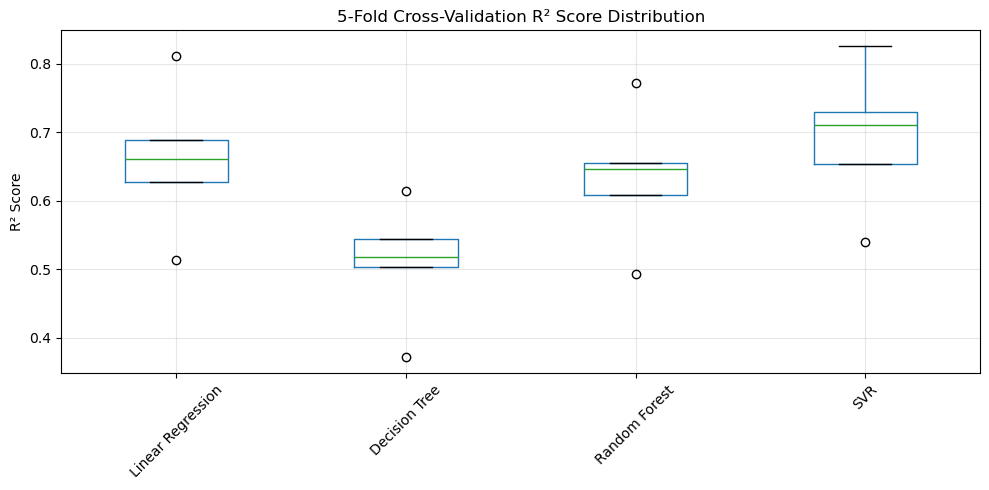

In [9]:
# Cross-validation box plot
cv_df = pd.DataFrame(cv_results)

plt.figure(figsize=(10, 5))
cv_df.boxplot()
plt.ylabel('R² Score')
plt.title('5-Fold Cross-Validation R² Score Distribution')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Best Model Selection

In [10]:
# Summary and best model identification
best_model = comparison_df.iloc[0]

print("=" * 60)
print("FINAL COMPARISON SUMMARY")
print("=" * 60)
print(f"\n{comparison_df.to_string(index=False)}")

print(f"\n{'=' * 60}")
print(f"BEST MODEL: {best_model['Model']}")
print(f"{'=' * 60}")
print(f"  R² Score : {best_model['R² Score']}")
print(f"  MAE      : {best_model['MAE']}")
print(f"  RMSE     : {best_model['RMSE']}")

print(f"\nNote: All 4 models were trained and tested on the exact same")
print(f"preprocessed dataset ({len(X_train)} train / {len(X_test)} test samples),")
print(f"making this a fair apples-to-apples comparison.")

FINAL COMPARISON SUMMARY

            Model    MAE   RMSE  R² Score
              SVR 0.7485 1.9520    0.7304
Linear Regression 1.0155 2.0974    0.6888
    Random Forest 1.1314 2.2095    0.6546
    Decision Tree 1.5896 2.5366    0.5448

BEST MODEL: SVR
  R² Score : 0.7304
  MAE      : 0.7485
  RMSE     : 1.952

Note: All 4 models were trained and tested on the exact same
preprocessed dataset (5285 train / 1322 test samples),
making this a fair apples-to-apples comparison.
